In [ ]:
"""
===============================================================================
Script Name: 01_gpu_ode_calibration.py
Description: Loads chunked tensor segments and trains a Physics-Informed 
             ODE to calibrate 7 thermal parameters (C, h0, h1, k01, k10, 
             q0, q1) using Backpropagation Through Time (BPTT) on a GPU.
             Includes interactive GPU selection, auto-resume, and CSV logging.
===============================================================================
"""

import os
import sys
import time
import warnings
import json
import subprocess
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from pathlib import Path
from tqdm import tqdm
from datetime import timedelta
import gc

# --- 1. CONFIGURATION ---
warnings.filterwarnings('ignore')

# Hyperparameters
BATCH_SIZE = 25000
EPOCHS = 50
LEARNING_RATE = 0.01
DT = 0.11  # Timestep in seconds

# ==========================================
# 2. GPU SELECTION & INITIALIZATION
# ==========================================
def select_gpu():
    """
    Selects GPU via CLI arg, env var, or interactive prompt (in that order).
    """
    for i, arg in enumerate(sys.argv):
        if arg == "--gpu" and i + 1 < len(sys.argv):
            gpu_id = int(sys.argv[i + 1])
            if gpu_id < torch.cuda.device_count():
                print(f"[SYSTEM] GPU {gpu_id} selected via CLI argument.")
                return gpu_id
            else:
                print(f"[!] CLI GPU {gpu_id} not found. Available: 0-{torch.cuda.device_count()-1}")

    env_gpu = os.environ.get("GPU_ID")
    if env_gpu is not None and env_gpu.isdigit():
        gpu_id = int(env_gpu)
        if gpu_id < torch.cuda.device_count():
            print(f"[SYSTEM] GPU {gpu_id} selected via GPU_ID environment variable.")
            return gpu_id
        else:
            print(f"[!] Env GPU_ID={gpu_id} not found. Available: 0-{torch.cuda.device_count()-1}")

    print("\n[SYSTEM] Live GPU Status:")
    try:
        subprocess.run(["nvidia-smi"])
    except FileNotFoundError:
        print("[WARNING] nvidia-smi not found. Cannot display GPU stats.")

    if not torch.cuda.is_available():
        print("[WARNING] No CUDA GPUs detected. Falling back to CPU.")
        return None

    while True:
        gpu_id = input("\n[SYSTEM] Enter the GPU ID you want to allocate (e.g., 0, 1) [Press Enter for '0']: ").strip()
        if not gpu_id:
            print("[SYSTEM] Defaulting to GPU 0.")
            return 0
        if gpu_id.isdigit():
            gpu_id_int = int(gpu_id)
            if gpu_id_int < torch.cuda.device_count():
                print(f"[SYSTEM] Manually locking script to GPU {gpu_id_int}.")
                return gpu_id_int
            else:
                print(f"[!] GPU {gpu_id_int} not found. Available GPUs: 0-{torch.cuda.device_count()-1}")
                continue
        print("[!] Invalid input. Please enter a valid integer ID.")

# --- 3. TERMINAL LOGGING UTILITY ---
class DualLogger:
    def __init__(self, filepath):
        self.terminal = sys.stdout
        self.log = open(filepath, "a", encoding="utf-8") # Append mode for resuming

    def write(self, message):
        self.terminal.write(message)
        self.log.write(message)

    def flush(self):
        self.terminal.flush()
        self.log.flush()

# --- 4. PHYSICS MODEL (THE ODE) ---
class ThermalODEModel(nn.Module):
    def __init__(self):
        super(ThermalODEModel, self).__init__()
        
        # 1. Define Priors (Starting Guesses)
        prior_C   = 141.735
        prior_h0  = 4.8713
        prior_h1  = 5.3871
        prior_k01 = 0.0780
        prior_k10 = 0.0281
        prior_q   = 0.0
        
        # 2. Define Physical Bounds [lower, upper]
        self.bounds = {
            'C':   (50.0, 300.0),
            'h0':  (1.0, 15.0),
            'h1':  (1.0, 15.0),
            'k01': (0.0, 0.5),
            'k10': (0.0, 0.5),
            'q0':  (-10.0, 10.0),
            'q1':  (-10.0, 10.0)
        }
        
        # 3. Initialize Raw Parameters (Inverse Sigmoid)
        def inv_sigmoid(val, low, high):
            norm = (val - low) / (high - low)
            norm = max(min(norm, 0.999), 0.001)
            return torch.log(torch.tensor(norm / (1.0 - norm)))

        self.raw_C   = nn.Parameter(inv_sigmoid(prior_C,   *self.bounds['C']))
        self.raw_h0  = nn.Parameter(inv_sigmoid(prior_h0,  *self.bounds['h0']))
        self.raw_h1  = nn.Parameter(inv_sigmoid(prior_h1,  *self.bounds['h1']))
        self.raw_k01 = nn.Parameter(inv_sigmoid(prior_k01, *self.bounds['k01']))
        self.raw_k10 = nn.Parameter(inv_sigmoid(prior_k10, *self.bounds['k10']))
        self.raw_q0  = nn.Parameter(inv_sigmoid(prior_q,   *self.bounds['q0']))
        self.raw_q1  = nn.Parameter(inv_sigmoid(prior_q,   *self.bounds['q1']))

    def get_physical_params(self):
        """Applies sigmoid to raw parameters to bind them within physical reality."""
        p = {}
        for name, bound in self.bounds.items():
            raw_val = getattr(self, f"raw_{name}")
            low, high = bound
            p[name] = low + torch.sigmoid(raw_val) * (high - low)
        return p

    # Uncomment below if using PyTorch 2.0+ for massive speedups
    # @torch.compile
    def forward(self, P0, P1, T0_init, T1_init, T_amb):
        """Simulates the thermal trajectories using Forward Euler integration."""
        params = self.get_physical_params()
        
        batch_size, seq_len = P0.shape
        
        # Pre-allocate to prevent torch.stack memory fragmentation
        T0_preds = torch.empty((batch_size, seq_len), device=P0.device)
        T1_preds = torch.empty((batch_size, seq_len), device=P1.device)
        
        T0_curr = T0_init
        T1_curr = T1_init
        T0_preds[:, 0] = T0_curr
        T1_preds[:, 0] = T1_curr
        
        inv_C = 1.0 / params['C']
        
        # Pre-calculate constants for the loop
        h0_T_amb_plus_q0 = (params['h0'] * T_amb) + params['q0']
        h1_T_amb_plus_q1 = (params['h1'] * T_amb) + params['q1']
        
        # Euler Integration Loop
        for t in range(seq_len - 1):
            dT0 = (P0[:, t] + params['k01'] * P1[:, t] - params['h0'] * T0_curr + h0_T_amb_plus_q0) * inv_C
            dT1 = (P1[:, t] + params['k10'] * P0[:, t] - params['h1'] * T1_curr + h1_T_amb_plus_q1) * inv_C
            
            T0_curr = T0_curr + DT * dT0
            T1_curr = T1_curr + DT * dT1
            
            T0_preds[:, t+1] = T0_curr
            T1_preds[:, t+1] = T1_curr
            
        return T0_preds, T1_preds


# --- 5. MAIN EXECUTION ---
def main():
    global script_name
    try:
        # Works when running as a normal .py script
        script_path = Path(__file__).resolve()
        script_name = script_path.stem
        project_root = script_path.parent.parent.parent
    except NameError:
        # Fallback for Jupyter Notebooks
        script_name = "01_gpu_ode_calibration"
        current_dir = Path.cwd() 
        project_root = current_dir.parent.parent
    
    # --- Device Setup ---
    gpu_id = select_gpu()
    if gpu_id is not None:
        torch.cuda.set_device(gpu_id)
        DEVICE = torch.device(f"cuda:{gpu_id}")
    else:
        DEVICE = torch.device("cpu")

    # --- Versioning & Path Initialization ---
    user_prefix = input("\nEnter version prefix (e.g., v1_base) [Press Enter for default 'v1']: ").strip()
    VERSION_PREFIX = user_prefix if user_prefix else "v1"

    # Input Data Directory
    data_dir = project_root / "Implementation" / "data" / "mit-supercloud-dataset" / "gpu" / "dual_gpu_0000_parquet_to_0019_parquet_cleaned_split_tensors"
    if not data_dir.exists():
        print(f"[ERROR] Cannot find tensor directory: {data_dir}")
        return

    prefix = "/home/sanke24839/"
    # Output Save Directory
    SAVE_DIR = project_root / "Implementation" / "models" / VERSION_PREFIX
    SAVE_DIR.mkdir(parents=True, exist_ok=True)
    
    log_path = SAVE_DIR / f"{script_name}_terminal_output.txt"
    sys.stdout = DualLogger(log_path)
    
    start_time = time.perf_counter()
    print("=" * 70)
    print(f"--- STARTING: {script_name.upper()} ---")
    print(f"[*] Version Prefix: {VERSION_PREFIX}")
    print(f"[*] Device: {DEVICE}")
    print(f"[*] Saving to: {str(SAVE_DIR).replace(prefix, '')}")
    print("=" * 70)

    # --- Background GPU Time-Series Logging ---
    gpu_logger_process = None
    if gpu_id is not None:
        gpu_csv_path = SAVE_DIR / f"{VERSION_PREFIX}_gpu{gpu_id}_timeseries.csv"
        try:
            # Queries specific metrics for the chosen GPU (-i), loops every 5 seconds (-l 5), writes to file (-f)
            smi_cmd = [
                "nvidia-smi",
                "--query-gpu=timestamp,utilization.gpu,utilization.memory,memory.used,temperature.gpu,power.draw",
                "--format=csv",
                "-i", str(gpu_id),
                "-l", "5", 
                "-f", str(gpu_csv_path)
            ]
            gpu_logger_process = subprocess.Popen(smi_cmd)
            print(f"[*] Started continuous GPU logging to: {gpu_csv_path.name}")
        except FileNotFoundError:
            print("[WARNING] nvidia-smi not found. Continuous GPU logging disabled.")

    # --- Setup Model, Optimizer, & Criterions ---
    model = ThermalODEModel().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    mse_criterion = nn.MSELoss(reduction='none') # For optimization
    mae_criterion = nn.L1Loss(reduction='none')  # For interpretable logging

    # --- Auto-Resume Logic ---
    RESUME_PATH = SAVE_DIR / f"{VERSION_PREFIX}_resume_checkpoint.pt"
    BEST_PATH = SAVE_DIR / f"{VERSION_PREFIX}_best_model.pt"
    CSV_LOG_PATH = SAVE_DIR / "training_log.csv"

    start_epoch = 1
    best_val_loss = float('inf')

    if RESUME_PATH.exists():
        print(f"\n[SYSTEM] Found existing checkpoint at: {RESUME_PATH.name}")
        print(f"[SYSTEM] Resuming training...")
        
        checkpoint = torch.load(RESUME_PATH, map_location=DEVICE, weights_only=False)
        
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        if 'scheduler_state_dict' in checkpoint:
            scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint['best_val_loss']
        
        # Restore RNG states
        torch.set_rng_state(checkpoint['torch_rng'].cpu().to(torch.uint8) if isinstance(checkpoint['torch_rng'], torch.Tensor) else torch.ByteTensor(checkpoint['torch_rng']))
        np.random.set_state(checkpoint['numpy_rng'])
        
        if torch.cuda.is_available() and 'cuda_rng' in checkpoint and checkpoint['cuda_rng'] is not None:
            cuda_rng = checkpoint['cuda_rng']
            torch.cuda.set_rng_state(cuda_rng.cpu().to(torch.uint8) if isinstance(cuda_rng, torch.Tensor) else torch.ByteTensor(cuda_rng))
            
        print(f"[SYSTEM] Resumed from Epoch {checkpoint['epoch']}. Best Val RMSE: {best_val_loss:.6f}")
    else:
        print(f"\n[SYSTEM] No checkpoint found. Starting fresh training.")
        # Initialize CSV header if starting fresh
        with open(CSV_LOG_PATH, "w") as f:
            f.write("epoch,train_rmse,val_rmse,train_mae,val_mae,current_lr,C,h0,h1,k01,k10,q0,q1,epoch_time_sec\n")

    # Discover chunks
    train_chunks = sorted(list(data_dir.glob("train_segments_part*.pt")))
    val_chunks = sorted(list(data_dir.glob("val_segments_part*.pt")))
    print(f"Found {len(train_chunks)} train chunks and {len(val_chunks)} val chunks.")

    try:
        # --- Training Loop ---
        for epoch in range(start_epoch, EPOCHS + 1):
            epoch_start_time = time.perf_counter()
            print(f"\n--- Epoch {epoch}/{EPOCHS} ---")
            
            # 1. TRAINING PHASE
            model.train()
            train_mse_accum = 0.0
            train_mae_accum = 0.0
            train_steps = 0
            
            for chunk_idx, chunk_file in enumerate(train_chunks):
                chunk_data = torch.load(chunk_file, map_location='cpu', weights_only=False)
                dataset = TensorDataset(
                    chunk_data['P0'], chunk_data['P1'], 
                    chunk_data['T0'], chunk_data['T1'],
                    chunk_data['T_amb'], chunk_data['valid_len']
                )
                # dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
                dataloader = DataLoader(
                    dataset,
                    batch_size=BATCH_SIZE,
                    shuffle=True,
                    num_workers=4,          # parallel CPU workers prefetch data
                    pin_memory=True,        # faster CPU→GPU transfer
                    persistent_workers=True
                )
                    
                for batch in tqdm(dataloader, desc=f"Train Chunk {chunk_idx+1}/{len(train_chunks)}", leave=False):
                    # P0, P1, T0_true, T1_true, T_amb, valid_len = [b.to(DEVICE) for b in batch]
                    P0, P1, T0_true, T1_true, T_amb, valid_len = [
                        b.to(DEVICE, non_blocking=True) for b in batch
                    ]
                    
                    optimizer.zero_grad()
                    
                    # Forward pass
                    T0_init, T1_init = T0_true[:, 0], T1_true[:, 0]
                    T0_pred, T1_pred = model(P0, P1, T0_init, T1_init, T_amb)
                    
                    # Create mask for valid timesteps
                    seq_len = P0.shape[1]
                    mask = torch.arange(seq_len, device=DEVICE).expand(len(valid_len), seq_len) < valid_len.unsqueeze(1)
                    
                    # Calculate MSE (for backprop)
                    mse_0 = mse_criterion(T0_pred, T0_true)
                    mse_1 = mse_criterion(T1_pred, T1_true)
                    # masked_mse = ((mse_0 + mse_1) * mask).sum() / mask.sum()
                    masked_mse = ((mse_0 + mse_1) * mask).sum() / (2 * mask.sum())
                    
                    # Calculate MAE (for tracking interpretability)
                    with torch.no_grad():
                        # mae_0 = mae_criterion(T0_pred, T0_true)
                        mae_0 = mae_criterion(T0_pred.detach(), T0_true)
                        # mae_1 = mae_criterion(T1_pred, T1_true)
                        mae_1 = mae_criterion(T1_pred.detach(), T1_true)
                        # masked_mae = ((mae_0 + mae_1) * mask).sum() / mask.sum()
                        masked_mae = ((mae_0 + mae_1) * mask).sum() / (2 * mask.sum())
    
                    # Backpropagate
                    masked_mse.backward()
                    optimizer.step()
                    
                    train_mse_accum += masked_mse.item()
                    train_mae_accum += masked_mae.item()
                    train_steps += 1
                    
                del chunk_data, dataset, dataloader
                # gc.collect()
    
            avg_train_mse = train_mse_accum / train_steps
            train_rmse = avg_train_mse ** 0.5
            train_mae = train_mae_accum / train_steps
            
            # 2. VALIDATION PHASE
            model.eval()
            val_mse_accum = 0.0
            val_mae_accum = 0.0
            val_steps = 0
            
            with torch.no_grad():
                for chunk_idx, chunk_file in enumerate(val_chunks):
                    chunk_data = torch.load(chunk_file, map_location='cpu', weights_only=False)
                    dataset = TensorDataset(
                        chunk_data['P0'], chunk_data['P1'], 
                        chunk_data['T0'], chunk_data['T1'],
                        chunk_data['T_amb'], chunk_data['valid_len']
                    )
                    # dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
                    dataloader = DataLoader(
                        dataset,
                        batch_size=BATCH_SIZE,
                        shuffle=False,
                        num_workers=4,          # parallel CPU workers prefetch data
                        pin_memory=True,        # faster CPU→GPU transfer
                        persistent_workers=True
                    )
                    
                    for batch in dataloader:
                        # P0, P1, T0_true, T1_true, T_amb, valid_len = [b.to(DEVICE) for b in batch]
                        P0, P1, T0_true, T1_true, T_amb, valid_len = [
                            b.to(DEVICE, non_blocking=True) for b in batch
                        ]
                        T0_init, T1_init = T0_true[:, 0], T1_true[:, 0]
                        
                        T0_pred, T1_pred = model(P0, P1, T0_init, T1_init, T_amb)
                        
                        seq_len = P0.shape[1]
                        mask = torch.arange(seq_len, device=DEVICE).expand(len(valid_len), seq_len) < valid_len.unsqueeze(1)
                        
                        # MSE
                        mse_0 = mse_criterion(T0_pred, T0_true)
                        mse_1 = mse_criterion(T1_pred, T1_true)
                        # masked_mse = ((mse_0 + mse_1) * mask).sum() / mask.sum()
                        masked_mse = ((mse_0 + mse_1) * mask).sum() / (2 * mask.sum())
                        
                        # MAE
                        mae_0 = mae_criterion(T0_pred, T0_true)
                        mae_1 = mae_criterion(T1_pred, T1_true)
                        # masked_mae = ((mae_0 + mae_1) * mask).sum() / mask.sum()
                        masked_mae = ((mae_0 + mae_1) * mask).sum() / (2 * mask.sum())
                        
                        val_mse_accum += masked_mse.item()
                        val_mae_accum += masked_mae.item()
                        val_steps += 1
                        
                    del chunk_data, dataset, dataloader
                    # gc.collect()
                    
            avg_val_mse = val_mse_accum / val_steps
            val_rmse = avg_val_mse ** 0.5
            val_mae = val_mae_accum / val_steps
            
            epoch_time = time.perf_counter() - epoch_start_time
            
            # 3. PRINT PROGRESS
            p = {k: v.item() for k, v in model.get_physical_params().items()}
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Time: {epoch_time:.1f}s | Train RMSE: {train_rmse:.4f} °C (MAE: {train_mae:.4f}) | Val RMSE: {val_rmse:.4f} °C (MAE: {val_mae:.4f}) | LR: {current_lr:.6f}")
            print(f"Params: C: {p['C']:.2f} | h0: {p['h0']:.4f} | h1: {p['h1']:.4f} | k01: {p['k01']:.4f} | k10: {p['k10']:.4f} | q0: {p['q0']:.4f} | q1: {p['q1']:.4f}")

            scheduler.step(val_rmse)
            
            # 4. LOGGING TO CSV
            with open(CSV_LOG_PATH, "a") as f:
                f.write(f"{epoch},{train_rmse:.6f},{val_rmse:.6f},{train_mae:.6f},{val_mae:.6f},{current_lr:.6f},{p['C']:.4f},{p['h0']:.4f},{p['h1']:.4f},{p['k01']:.4f},{p['k10']:.4f},{p['q0']:.4f},{p['q1']:.4f},{epoch_time:.2f}\n")
    
            # 5. CHECKPOINTING
            is_best = val_rmse < best_val_loss
            if is_best:
                best_val_loss = val_rmse  # Update best_val_loss before saving
    
            checkpoint_state = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_loss': best_val_loss,
                'torch_rng': torch.get_rng_state(),
                'numpy_rng': np.random.get_state(),
                'cuda_rng': torch.cuda.get_rng_state() if torch.cuda.is_available() else None
            }
    
            # Save standard resume checkpoint (now contains the updated best_val_loss)
            torch.save(checkpoint_state, RESUME_PATH)
    
            # Save best model checkpoint if validation loss improves
            if is_best:
                torch.save(checkpoint_state, BEST_PATH)
                
                with open(SAVE_DIR / "calibrated_physics.json", "w") as f:
                    json.dump(p, f, indent=4)
                print(">>> New best parameters saved! <<<")
    
        # --- END SUMMARY ---
        end_time = time.perf_counter()
        formatted_time = str(timedelta(seconds=int(end_time - start_time)))
        
        print("\n" + "=" * 70)
        print("=== CALIBRATION COMPLETE ===")
        print(f"Total Time : {formatted_time}")
        print(f"Best Val RMSE : {best_val_loss:.4f} °C")
        print(f"Results saved to: {SAVE_DIR}")
        print("=" * 70)

    finally:
        # This guarantees the background GPU logger is killed even if the script crashes
        if gpu_logger_process is not None:
            gpu_logger_process.terminate()
            gpu_logger_process.wait()
            print("[*] Background GPU logger terminated.")

        # Safely detach the dual logger
        if hasattr(sys.stdout, 'terminal'):
            sys.stdout = sys.stdout.terminal

if __name__ == "__main__":
    main()
    

In [ ]:
# GEMINI TEST


[SYSTEM] Live GPU Status:
Thu Apr  2 10:44:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A4500               Off |   00000000:3B:00.0 Off |                  Off |
| 30%   48C    P8             18W /  200W |    7683MiB /  20470MiB |      0%      Default |
|                                         |                        |                  N/A |
+--------------------


[SYSTEM] Enter the GPU ID for testing (e.g., 0, 1) [Press Enter for '0']:  1

Enter version prefix to test (e.g., v1) [Press Enter for 'v1']:  ode_v1


--- STARTING TEST EVALUATION: ode_v1 ---
[*] Loaded Best Model from Epoch 35 (Val RMSE: 6.1671)
[*] Found 1 test chunks.

Starting Test Evaluation...


Test Chunk 1/1: 100%|██████████| 2/2 [00:16<00:00,  8.23s/it]



=== TEST SET PERFORMANCE ===
Test RMSE : 5.0555 °C
Test MAE  : 3.6399 °C
Eval Time : 20.2s
[*] Generating static global performance plots...
[*] Saved static plots to: global_test_performance.png
[*] Saved 5 interactive HTML plots to test_results/


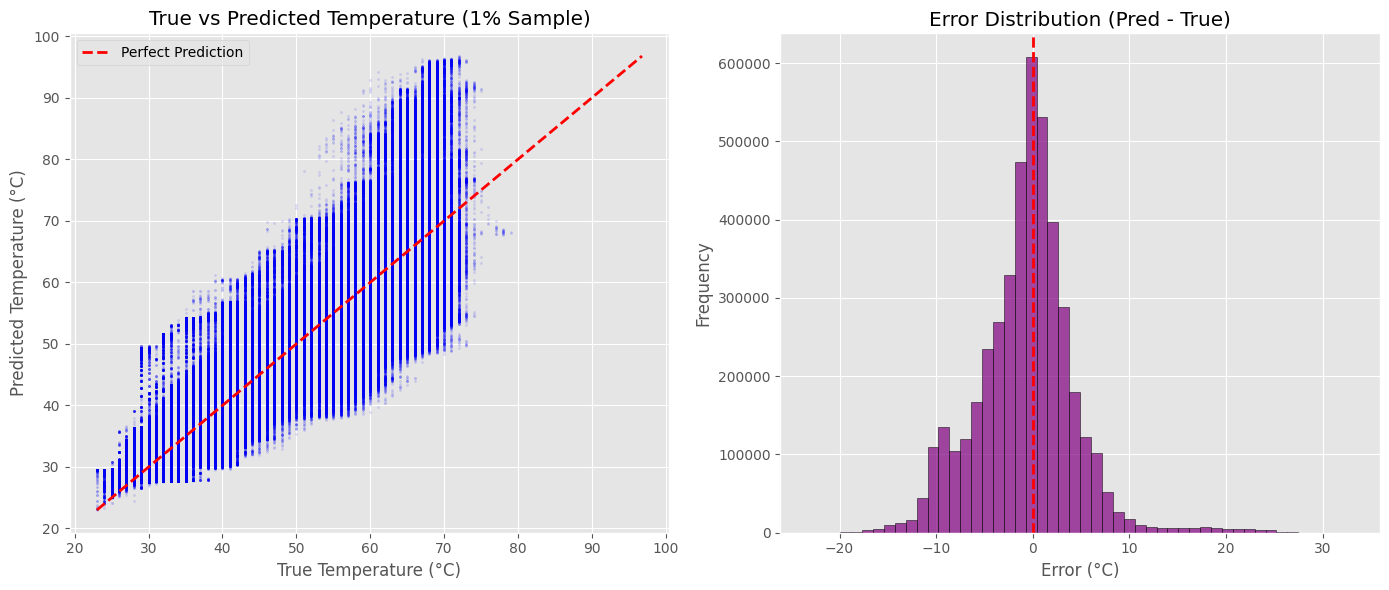

In [1]:
"""
===============================================================================
Script Name: 02_ode_testing.py
Description: Evaluates the calibrated Physics-Informed ODE on the unseen 
             test set. Computes global test metrics, plots overall error 
             distributions, and generates interactive HTML time-series 
             comparisons for specific jobs using Plotly.
===============================================================================
"""

import os
import sys
import time
import warnings
import json
import subprocess
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from torch.utils.data import TensorDataset, DataLoader
from pathlib import Path
from tqdm import tqdm
import gc

# --- 1. CONFIGURATION ---
warnings.filterwarnings('ignore')

BATCH_SIZE = 25000
DT = 0.11  # Timestep in seconds
NUM_HTML_PLOTS = 5  # How many interactive HTML files to generate

# ==========================================
# 2. GPU SELECTION & INITIALIZATION
# ==========================================
def select_gpu():
    """Selects GPU interactively or defaults to CPU."""
    
    # --- ADD THIS BLOCK ---
    print("\n[SYSTEM] Live GPU Status:")
    try:
        subprocess.run(["nvidia-smi"])
    except FileNotFoundError:
        print("[WARNING] nvidia-smi not found. Cannot display GPU stats.")
    # ----------------------

    if not torch.cuda.is_available():
        print("[WARNING] No CUDA GPUs detected. Falling back to CPU.")
        return None

    while True:
        gpu_id = input("\n[SYSTEM] Enter the GPU ID for testing (e.g., 0, 1) [Press Enter for '0']: ").strip()
        if not gpu_id:
            return 0
        if gpu_id.isdigit() and int(gpu_id) < torch.cuda.device_count():
            return int(gpu_id)
        print(f"[!] Invalid ID. Available GPUs: 0-{torch.cuda.device_count()-1}")

class DualLogger:
    def __init__(self, filepath):
        self.terminal = sys.stdout
        self.log = open(filepath, "w", encoding="utf-8")

    def write(self, message):
        self.terminal.write(message)
        self.log.write(message)

    def flush(self):
        self.terminal.flush()
        self.log.flush()

# --- 3. PHYSICS MODEL (Must match training exactly) ---
class ThermalODEModel(nn.Module):
    def __init__(self):
        super(ThermalODEModel, self).__init__()
        
        prior_C   = 141.735
        prior_h0  = 4.8713
        prior_h1  = 5.3871
        prior_k01 = 0.0780
        prior_k10 = 0.0281
        prior_q   = 0.0
        
        self.bounds = {
            'C':   (50.0, 300.0),
            'h0':  (1.0, 15.0),
            'h1':  (1.0, 15.0),
            'k01': (0.0, 0.5),
            'k10': (0.0, 0.5),
            'q0':  (-10.0, 10.0),
            'q1':  (-10.0, 10.0)
        }
        
        def inv_sigmoid(val, low, high):
            norm = (val - low) / (high - low)
            norm = max(min(norm, 0.999), 0.001)
            return torch.log(torch.tensor(norm / (1.0 - norm)))

        self.raw_C   = nn.Parameter(inv_sigmoid(prior_C,   *self.bounds['C']))
        self.raw_h0  = nn.Parameter(inv_sigmoid(prior_h0,  *self.bounds['h0']))
        self.raw_h1  = nn.Parameter(inv_sigmoid(prior_h1,  *self.bounds['h1']))
        self.raw_k01 = nn.Parameter(inv_sigmoid(prior_k01, *self.bounds['k01']))
        self.raw_k10 = nn.Parameter(inv_sigmoid(prior_k10, *self.bounds['k10']))
        self.raw_q0  = nn.Parameter(inv_sigmoid(prior_q,   *self.bounds['q0']))
        self.raw_q1  = nn.Parameter(inv_sigmoid(prior_q,   *self.bounds['q1']))

    def get_physical_params(self):
        p = {}
        for name, bound in self.bounds.items():
            raw_val = getattr(self, f"raw_{name}")
            low, high = bound
            p[name] = low + torch.sigmoid(raw_val) * (high - low)
        return p

    def forward(self, P0, P1, T0_init, T1_init, T_amb):
        params = self.get_physical_params()
        batch_size, seq_len = P0.shape
        
        T0_preds = torch.empty((batch_size, seq_len), device=P0.device)
        T1_preds = torch.empty((batch_size, seq_len), device=P1.device)
        
        T0_curr = T0_init
        T1_curr = T1_init
        T0_preds[:, 0] = T0_curr
        T1_preds[:, 0] = T1_curr
        
        inv_C = 1.0 / params['C']
        h0_T_amb_plus_q0 = (params['h0'] * T_amb) + params['q0']
        h1_T_amb_plus_q1 = (params['h1'] * T_amb) + params['q1']
        
        for t in range(seq_len - 1):
            dT0 = (P0[:, t] + params['k01'] * P1[:, t] - params['h0'] * T0_curr + h0_T_amb_plus_q0) * inv_C
            dT1 = (P1[:, t] + params['k10'] * P0[:, t] - params['h1'] * T1_curr + h1_T_amb_plus_q1) * inv_C
            
            T0_curr = T0_curr + DT * dT0
            T1_curr = T1_curr + DT * dT1
            
            T0_preds[:, t+1] = T0_curr
            T1_preds[:, t+1] = T1_curr
            
        return T0_preds, T1_preds

# --- 4. PLOTTING UTILITIES ---
def generate_interactive_html(P0, P1, T0_true, T1_true, T0_pred, T1_pred, valid_len, job_id, save_dir):
    """Creates a plotly interactive widget showing power inputs vs temp predictions."""
    
    time_axis = np.arange(valid_len) * DT
    
    # Slice arrays to valid length
    P0, P1 = P0[:valid_len], P1[:valid_len]
    T0_t, T1_t = T0_true[:valid_len], T1_true[:valid_len]
    T0_p, T1_p = T0_pred[:valid_len], T1_pred[:valid_len]

    fig = make_subplots(specs=[[{"secondary_y": True}]])

    # True Temperatures (Solid Lines)
    fig.add_trace(go.Scatter(x=time_axis, y=T0_t, name="GPU 0 True Temp", line=dict(color='blue', width=2)), secondary_y=False)
    fig.add_trace(go.Scatter(x=time_axis, y=T1_t, name="GPU 1 True Temp", line=dict(color='purple', width=2)), secondary_y=False)
    
    # Predicted Temperatures (Dashed Lines)
    fig.add_trace(go.Scatter(x=time_axis, y=T0_p, name="GPU 0 Pred Temp", line=dict(color='cyan', width=2, dash='dash')), secondary_y=False)
    fig.add_trace(go.Scatter(x=time_axis, y=T1_p, name="GPU 1 Pred Temp", line=dict(color='magenta', width=2, dash='dash')), secondary_y=False)

    # Power Draw (Filled Area, Secondary Y)
    fig.add_trace(go.Scatter(x=time_axis, y=P0, name="GPU 0 Power", fill='tozeroy', line=dict(color='rgba(255, 100, 100, 0.2)'), showlegend=True), secondary_y=True)
    fig.add_trace(go.Scatter(x=time_axis, y=P1, name="GPU 1 Power", fill='tozeroy', line=dict(color='rgba(255, 165, 0, 0.2)'), showlegend=True), secondary_y=True)

    fig.update_layout(
        title=f"ODE Prediction vs Reality (Job ID: {job_id})",
        xaxis_title="Time (Seconds)",
        hovermode="x unified",
        template="plotly_dark"
    )
    
    fig.update_yaxes(title_text="Temperature (°C)", secondary_y=False)
    fig.update_yaxes(title_text="Power Draw (W)", secondary_y=True, range=[0, max(max(P0), max(P1)) * 1.5]) # Scale power down visually

    save_path = save_dir / f"job_{job_id}_interactive.html"
    fig.write_html(str(save_path))

# --- 5. MAIN EXECUTION ---
def main():
    try:
        # Works when running as a normal .py script
        script_path = Path(__file__).resolve()
        script_name = script_path.stem
        project_root = script_path.parent.parent.parent
    except NameError:
        # Fallback for Jupyter Notebooks
        script_name = "08_ode_testing"
        current_dir = Path.cwd() 
        
        # NOTE: If your notebook is saved in a different folder depth than 
        # your script was, you might need to adjust the number of '.parent' calls here
        project_root = current_dir.parent.parent 
    
    # --- Setup ---
    gpu_id = select_gpu()
    DEVICE = torch.device(f"cuda:{gpu_id}" if gpu_id is not None else "cpu")
    if gpu_id is not None:
        torch.cuda.set_device(gpu_id)

    VERSION_PREFIX = input("\nEnter version prefix to test (e.g., v1) [Press Enter for 'v1']: ").strip()
    VERSION_PREFIX = VERSION_PREFIX if VERSION_PREFIX else "v1"

    data_dir = project_root / "Implementation" / "data" / "mit-supercloud-dataset" / "gpu" / "dual_gpu_0000_parquet_to_0019_parquet_cleaned_split_tensors"
    MODEL_DIR = project_root / "Implementation" / "models" / VERSION_PREFIX
    SAVE_DIR = MODEL_DIR / "test_results"
    SAVE_DIR.mkdir(parents=True, exist_ok=True)
    
    log_path = SAVE_DIR / "test_evaluation_log.txt"
    sys.stdout = DualLogger(log_path)
    
    print("=" * 70)
    print(f"--- STARTING TEST EVALUATION: {VERSION_PREFIX} ---")
    print("=" * 70)

    # --- Load Model ---
    BEST_PATH = MODEL_DIR / f"{VERSION_PREFIX}_best_model.pt"
    if not BEST_PATH.exists():
        print(f"[ERROR] Could not find best model at: {BEST_PATH}")
        return
        
    model = ThermalODEModel().to(DEVICE)
    checkpoint = torch.load(BEST_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    print(f"[*] Loaded Best Model from Epoch {checkpoint['epoch']} (Val RMSE: {checkpoint['best_val_loss']:.4f})")
    
    # --- Metrics Setup ---
    mse_criterion = nn.MSELoss(reduction='none')
    mae_criterion = nn.L1Loss(reduction='none')
    
    test_chunks = sorted(list(data_dir.glob("test_segments_part*.pt")))
    print(f"[*] Found {len(test_chunks)} test chunks.")

    test_mse_accum = 0.0
    test_mae_accum = 0.0
    test_steps = 0
    
    # For global static plotting (we will sample 1% of points to not crash RAM)
    sampled_true = []
    sampled_pred = []
    
    # For interactive HTMLs
    htmls_generated = 0

    print("\nStarting Test Evaluation...")
    start_time = time.perf_counter()
    
    with torch.no_grad():
        for chunk_idx, chunk_file in enumerate(test_chunks):
            chunk_data = torch.load(chunk_file, map_location='cpu', weights_only=False)
            dataset = TensorDataset(
                chunk_data['P0'], chunk_data['P1'], 
                chunk_data['T0'], chunk_data['T1'],
                chunk_data['T_amb'], chunk_data['valid_len']
            )
            job_ids = chunk_data['job_ids']
            
            dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
            
            # Since dataloader strips job_ids (lists don't batch well natively), we track indices
            current_idx = 0
            
            for batch in tqdm(dataloader, desc=f"Test Chunk {chunk_idx+1}/{len(test_chunks)}"):
                P0, P1, T0_true, T1_true, T_amb, valid_len = [b.to(DEVICE) for b in batch]
                batch_size = P0.shape[0]
                T0_init, T1_init = T0_true[:, 0], T1_true[:, 0]
                
                T0_pred, T1_pred = model(P0, P1, T0_init, T1_init, T_amb)
                
                seq_len = P0.shape[1]
                mask = torch.arange(seq_len, device=DEVICE).expand(len(valid_len), seq_len) < valid_len.unsqueeze(1)
                
                # --- Metrics Calculation ---
                mse_0 = mse_criterion(T0_pred, T0_true)
                mse_1 = mse_criterion(T1_pred, T1_true)
                masked_mse = ((mse_0 + mse_1) * mask).sum() / (2 * mask.sum())
                
                mae_0 = mae_criterion(T0_pred, T0_true)
                mae_1 = mae_criterion(T1_pred, T1_true)
                masked_mae = ((mae_0 + mae_1) * mask).sum() / (2 * mask.sum())
                
                test_mse_accum += masked_mse.item()
                test_mae_accum += masked_mae.item()
                test_steps += 1
                
                # --- Collect Data for Global Plots (Sample 1 out of 100 valid points) ---
                valid_mask_flat = mask.flatten()
                t0_t_flat = T0_true.flatten()[valid_mask_flat].cpu().numpy()
                t0_p_flat = T0_pred.flatten()[valid_mask_flat].cpu().numpy()
                t1_t_flat = T1_true.flatten()[valid_mask_flat].cpu().numpy()
                t1_p_flat = T1_pred.flatten()[valid_mask_flat].cpu().numpy()
                
                sampled_true.extend(t0_t_flat[::100])
                sampled_true.extend(t1_t_flat[::100])
                sampled_pred.extend(t0_p_flat[::100])
                sampled_pred.extend(t1_p_flat[::100])
                
                # --- Generate Interactive HTMLs for first few jobs ---
                for i in range(batch_size):
                    if htmls_generated < NUM_HTML_PLOTS:
                        v_len = valid_len[i].item()
                        if v_len > 100: # Only plot jobs that have a decent length
                            j_id = job_ids[current_idx + i]
                            generate_interactive_html(
                                P0[i].cpu().numpy(), P1[i].cpu().numpy(),
                                T0_true[i].cpu().numpy(), T1_true[i].cpu().numpy(),
                                T0_pred[i].cpu().numpy(), T1_pred[i].cpu().numpy(),
                                v_len, j_id, SAVE_DIR
                            )
                            htmls_generated += 1
                
                current_idx += batch_size
                
            del chunk_data, dataset, dataloader
            gc.collect()

    # --- Final Test Metrics ---
    avg_test_mse = test_mse_accum / test_steps
    final_test_rmse = avg_test_mse ** 0.5
    final_test_mae = test_mae_accum / test_steps
    total_time = time.perf_counter() - start_time

    print("\n" + "=" * 70)
    print("=== TEST SET PERFORMANCE ===")
    print(f"Test RMSE : {final_test_rmse:.4f} °C")
    print(f"Test MAE  : {final_test_mae:.4f} °C")
    print(f"Eval Time : {total_time:.1f}s")
    print("=" * 70)

    # --- Generate Static Global Plots ---
    print("[*] Generating static global performance plots...")
    sampled_true = np.array(sampled_true)
    sampled_pred = np.array(sampled_pred)
    errors = sampled_pred - sampled_true

    plt.style.use('ggplot')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Scatter (True vs Pred)
    ax1.scatter(sampled_true, sampled_pred, alpha=0.1, s=2, color='blue')
    min_val, max_val = min(sampled_true.min(), sampled_pred.min()), max(sampled_true.max(), sampled_pred.max())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Perfect Prediction")
    ax1.set_title("True vs Predicted Temperature (1% Sample)")
    ax1.set_xlabel("True Temperature (°C)")
    ax1.set_ylabel("Predicted Temperature (°C)")
    ax1.legend()

    # Plot 2: Error Histogram
    ax2.hist(errors, bins=50, color='purple', alpha=0.7, edgecolor='black')
    ax2.axvline(0, color='red', linestyle='dashed', linewidth=2)
    ax2.set_title("Error Distribution (Pred - True)")
    ax2.set_xlabel("Error (°C)")
    ax2.set_ylabel("Frequency")

    plt.tight_layout()
    plot_path = SAVE_DIR / "global_test_performance.png"
    plt.savefig(plot_path, dpi=300)
    print(f"[*] Saved static plots to: {plot_path.name}")
    print(f"[*] Saved {htmls_generated} interactive HTML plots to {SAVE_DIR.name}/")

    sys.stdout = sys.stdout.terminal

if __name__ == "__main__":
    main()
    